In [ ]:
# !pip install torchvision
import torch  # complete deep learning engine
import os  # manage folders/files
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

### Dataset which we use here

`Dataset` : [Large-scale CelebaFaces Attributes (**CelebaA**) Dataset](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html)

### Steps to extract dataset:
- go on https://drive.google.com/drive/folders/0B7EVK8r0v71pTUZsaXdaSnZBZzg?resourcekey=0-rJlzl934LzC-Xp28GeIBzQ
- find the file - `img_align_celeba.zip`
- organize this file to your drive as **add shortcut**

## Google Drive Connect
Mounts the Google Drive into a Colab filesystem  
path becomes -> '/content/drive/MyDrive/ 

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# extract zip file from google drive
!unzip -q /content/drive/MyDrive/datasets/img_align_celeba.zip -d /content/

## Create Dataset & DataLoader for GAN

### Custom Dataset Class

Creates a custom dataset for all images
> Image Floder -> Load Image -> Transform -> Return One Image

Used to supply real images to GAN.

In [ ]:
# Images Load ==> transform => dataset of all imgs
class ImageProcessor:
    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        # list of paths of all images
        self.all_img_paths = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    
    # by using this ImageProcessor we create a datasets of all imgs
    # and than pass this dataset to dataloader
    # DataLoader -> expect 2 imp function from this class (func name must not change)

    # Required func-1 | Total Images
    def __len__(self):
        return len(self.all_img_paths)
    
    # Required func-2 | Get one image
    def __getitem__(self, idx):
        # load image
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        # RGB -> ensures all images have 3 channels.
        # GAN expects fixed image shape: (3, H, W)

        # Transforms image before training
        if self.transformations:
            img = self.transformations(img)

        return img

In [ ]:
# dataset path : folder containing CelebA images
root_dir_path = "/content/img_align_celeba"

# Images Transforms: set transforms for each image
transformations = transforms.Compose({
    transforms.CenterCrop(178), # Removes extra top/buttom area (178x218 => 178x178) Square Crop
    transforms.Resize(64), # 64x64 | used for faster GAN training
    transforms.ToTensor(), # PIL Image -> PyTorch Tensor | Shape becomes: [3, 64, 64]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # convert pixel range | [0, 1] => [-1, 1]
})

# Why Normalize:
# Generator often uses tanh, which output range [-1, 1]
# Real images should match same range that's why we normalize 

### Create Dataset

In [25]:
dataset = ImageProcessor(
    root_dir_path,
    transformations=transformations
)
print(f"loaded {len(dataset)} images")

loaded 202599 images


### Create DataLoader

In [ ]:
# Create DataLoader | Dataset => Dataloader
dataloader = DataLoader(
    dataset,
    batch_size=128, # 128 images per batch
    shuffle=True # Randomize images every epoch
)

# DataLoader Creates mini-batches for training.
# Each batch becomes: [128(images), 3(channels), 64, 64]

## Generator Network

The **Generator** creates fake images from random noise.

Its goal is to fool the **Discriminator**

> Noise Vector -> Neural Network -> Fake Face Image

```python
Input: Random Noise [128,100]
        ↓
Linear Layers
        ↓
12288 Values
        ↓
Reshape
        ↓
Output: Fake Images [128,3,64,64]
```

Generator tries to learn:  
eyes, noise, hair, face structue - from training data.

In [27]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [ ]:
class Generator(nn.Module): ## nn.Module is base class for neural network 
    def __init__(self, z_dim=100, img_channels=3): # z_dim = size of random noise vector | 3 = RGB 
        super(Generator, self).__init__() # Initializes PyTorch neural network class 

        # Fully Connected (dense) Layers
        self.model = nn.Sequential(
            # Layer-1
            nn.Linear(z_dim, 256), # 100 => 256 neurons | Expand features
            nn.ReLU(), # Non-linearity

            # Layer-2
            nn.Linear(256, 512),
            nn.ReLU(),

            # Layer-3
            nn.Linear(512, 1024),
            nn.ReLU(),

            # Final Output Layer
            nn.Linear(1024, 64 * 64 * img_channels), # (64x64x3 = 12288) These values represents pixels of fake image.
            nn.Tanh() # generate in range -> (-1, 1)
            # real images were normalized to [-1, 1] so fake images must match same range
        )
    
    # Forward Pass
    def forward(self, z): # z = random noise input
        # Pass through network
        img = self.model(z) # return: [128, 12288] currently flat vector, not image shape.
        # 128 noise vectors in one batch

        # Reshape to Image
        img = img.view(img.size(0), 3, 64, 64) # view() convert vector to image 
        # img.size(0) => batch size (128)
        # [128, 12288] => [128, 3, 64, 64]
        # 3 = RGB channels
        # 64, 64 = image size

        return img # reaturn fake image batch
    
    # Final Outpput Shape
    # single fake img dim: [64 x 64 x 3] - (3D)
    # batch of 128 imgs: [128, 3, 64, 64] - (4D)

## Discriminator Network

The **Discriminator** checks whether an image is:
- **Real** (from dataset)
- **Fake** (generated by Genrator)

> Image -> Neural Network -> Probability (Real / Fake)

```python
Image [128,3,64,64]
        ↓
Flatten
        ↓
Linear Layers
        ↓
Probability [128,1]
```

In [ ]:
# Creates Discriminator model using Pytorch.
class Discriminator(nn.Module):
    def __init__(self, img_channels=3):
        super(Discriminator, self).__init__()

        # Fully Connected Layer
        self.model = nn.Sequential(
            # fully connected (Linear) layers need 1D input.
            nn.Flatten(), # [batch, 3, 64, 64] => [batch, 12288]

            nn.Linear(img_channels * 64 * 64, 1024),  # 12288 -> 1024 | Learn image patterns
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            # LeakyReLU - allows small negative values. Prevents dead neurons and improves GAN training statbility.

            # Output Layer
            nn.Linear(256, 1),
            nn.Sigmoid() # probability of bening real/fake
        )

    # Forward Pass
    def forward(self, img):
        return self.model(img) # return classification
        # output shape: [128, 1]
        # Each image gets one probability score.

## Loss Function & OPtimizers

**BCELoss** Compares:
> Predicted Output vs True Label

In [ ]:
# Loss Function 
GAN_loss = nn.BCELoss() # Binary Cross Entropy Loss

# create Generator model
generator = Generator()

# Gnerator OPtimizer
g_optimizer = optim.Adam(
    generator.parameters(), # all trainable generator weights
    lr=0.0002, # learning rate
    betas=(0.5, 0.999) # momentum values
)
# lr & betas => these are common stabe GAN defaults, helps to smoother training

# create Discriminator model
discriminator = Discriminator()

# Discriminator Optimizer : updates discriminator weights during training
d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

# Note: Generator & Discriminator are different networks.
# Each needs separate parameter updates.
# Generator weights != Discriminator weights

## Device Setup

In [31]:
# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device =  torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device is {device}")

device is cuda


## Move Models to Device

if model on GPU, data must also be on GPU.  
otherwise error occurs: "Expected all tensors to be on same device"

In [32]:
generator = generator.to(device)
discriminator = discriminator.to(device)

## Training the GAN

training function parameters:
- `generator` = Fake Image creator
- `discriminator` = Real/Fake detector
- `dataloader` = Real image batches
- `epochs` = Full dataset repetitions

### Full GAN Battle Flow

Real Image ---> Discriminator --> Real

> Noise -> Generator -> Fake Images -> Discriminator -> Fake

**Generator** tries to fool `Discriminator`  

**Discriminator** tries to catch `Generator`

In [ ]:
def Train(generator, discriminator, dataloader, epochs=10):
    # Epoch Loop
    for epoch in range(epochs): # one epoch = model sees full dataset onece.
        # Batch Loop
        for i, imgs in enumerate(dataloader): # load image batches | batch shape = [128, 3, 64, 64]
            real_imgs = imgs.to(device) # move batch to device(GPU/CPU)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1, 1, 1...]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0, 0, 0...]

            # Part-1: ------------Train Discriminator------------ (discriminator learns)
            d_optimizer.zero_grad() # reset prevoius gradients

            # Generate Fake Images
            fake_imgs = generator(
                torch.randn(batch_size, 100).to(device)
                # creator random noise: [128, 100]
                # generator outputs: [128, 3, 64, 64]
            )

            # Loss on Real Images
            real_loss = GAN_loss(
                discriminator(real_imgs),
                real_labels
            ) # how better prediction real image by DisCriminator

            # Loss on Fake Images
            fake_loss = GAN_loss(
                discriminator(fake_imgs.detach()), 
                fake_labels
            ) # what loss calculate for fake image
            # .detach() ->stops gradient flow to generator.
            # it insure that During discriminator training, only Discriminator should update. 
            # Generator must stay frozen

            # overall discriminator loss
            d_loss  = (real_loss + fake_loss) / 2

            # Backpropagation : compute gradients & update discriminator weights
            d_loss.backward()
            d_optimizer.step()

            # Part-2: -----------------Train the Generator------------------ (make fake images look real)
            g_optimizer.zero_grad() # clear old gradients

            # Generator Loas
            g_loss = GAN_loss(
                discriminator(fake_imgs), 
                real_labels # genrator wants discriminator to believe fake images are real. target=1
            )

            # update generator weights
            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"for each: {epoch+1}/{epochs}... batch: {i+1}... G-loss:{g_loss}... D-loss:{d_loss}")
            

        # show generated progress after each epoch
        save_generated_images(generator, epoch, device)

In [ ]:
import matplotlib.pyplot as plt
import torchvision

# generates sample fake images.
def save_generated_images(generater, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device) # create 8 random inputs (noise)
    generated_imgs = generater(z).detach().cpu()
    # detach() => no gradients
    # cpu -> move to CPU for plotting

    # Make Gride
    grid = torchvision.utils.make_grid( # create 4x2 Images grid
        generated_imgs, 
        nrow=4, 
        normalize=True
    )
    
    # Display generated faces
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

## Start Training

for each: 1/5... batch: 1... G-loss:3.0824456214904785... D-loss:0.20332056283950806
for each: 1/5... batch: 51... G-loss:5.565176963806152... D-loss:0.2660978138446808
for each: 1/5... batch: 101... G-loss:3.569645881652832... D-loss:0.11303345113992691
for each: 1/5... batch: 151... G-loss:3.9509801864624023... D-loss:0.03147214278578758
for each: 1/5... batch: 201... G-loss:3.6754727363586426... D-loss:0.1188776046037674
for each: 1/5... batch: 251... G-loss:2.819779872894287... D-loss:0.2031354159116745
for each: 1/5... batch: 301... G-loss:3.6358656883239746... D-loss:0.07399018108844757
for each: 1/5... batch: 351... G-loss:3.3039612770080566... D-loss:0.3574787676334381
for each: 1/5... batch: 401... G-loss:3.45255708694458... D-loss:0.09857424348592758
for each: 1/5... batch: 451... G-loss:6.389462471008301... D-loss:0.23161357641220093
for each: 1/5... batch: 501... G-loss:2.310434579849243... D-loss:0.24196232855319977
for each: 1/5... batch: 551... G-loss:2.9697048664093018.

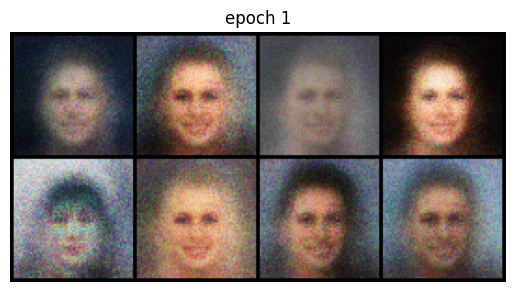

for each: 2/5... batch: 1... G-loss:2.821070909500122... D-loss:0.1854613721370697
for each: 2/5... batch: 51... G-loss:3.8510196208953857... D-loss:0.24408936500549316
for each: 2/5... batch: 101... G-loss:2.2014079093933105... D-loss:0.33769434690475464
for each: 2/5... batch: 151... G-loss:1.8725223541259766... D-loss:0.4100050926208496
for each: 2/5... batch: 201... G-loss:3.224891185760498... D-loss:0.336029589176178
for each: 2/5... batch: 251... G-loss:5.367520332336426... D-loss:0.4220079183578491
for each: 2/5... batch: 301... G-loss:2.1593120098114014... D-loss:0.3238166868686676
for each: 2/5... batch: 351... G-loss:1.9895596504211426... D-loss:0.32269832491874695
for each: 2/5... batch: 401... G-loss:2.21256160736084... D-loss:0.3505203425884247
for each: 2/5... batch: 451... G-loss:2.9628055095672607... D-loss:0.3664209842681885
for each: 2/5... batch: 501... G-loss:2.615088701248169... D-loss:0.4098215699195862
for each: 2/5... batch: 551... G-loss:2.349539279937744... D-

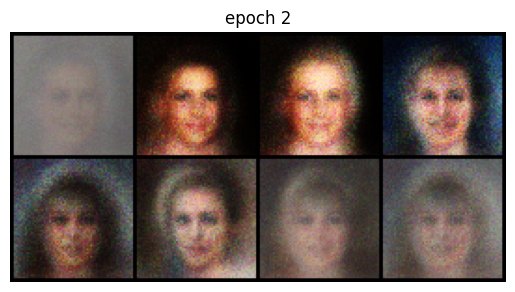

for each: 3/5... batch: 1... G-loss:2.3278965950012207... D-loss:0.3502626419067383
for each: 3/5... batch: 51... G-loss:2.339357852935791... D-loss:0.357563853263855
for each: 3/5... batch: 101... G-loss:2.549844264984131... D-loss:0.3082996606826782
for each: 3/5... batch: 151... G-loss:2.014683246612549... D-loss:0.42919421195983887
for each: 3/5... batch: 201... G-loss:1.8969438076019287... D-loss:0.39691025018692017
for each: 3/5... batch: 251... G-loss:3.0569658279418945... D-loss:0.3195760250091553
for each: 3/5... batch: 301... G-loss:2.4662833213806152... D-loss:0.4000213146209717
for each: 3/5... batch: 351... G-loss:2.293313503265381... D-loss:0.43406498432159424
for each: 3/5... batch: 401... G-loss:1.95303213596344... D-loss:0.4017004370689392
for each: 3/5... batch: 451... G-loss:1.824315071105957... D-loss:0.470529168844223
for each: 3/5... batch: 501... G-loss:2.085142135620117... D-loss:0.4250792860984802
for each: 3/5... batch: 551... G-loss:1.8295795917510986... D-lo

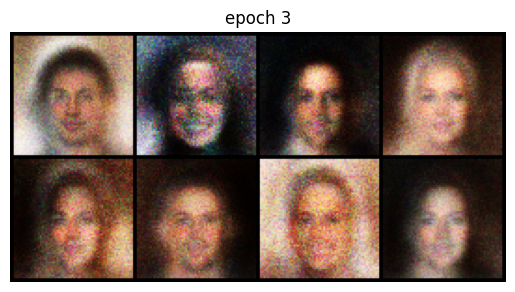

for each: 4/5... batch: 1... G-loss:2.322587013244629... D-loss:0.3883483409881592
for each: 4/5... batch: 51... G-loss:2.2171459197998047... D-loss:0.43877801299095154
for each: 4/5... batch: 101... G-loss:1.744694709777832... D-loss:0.5829192399978638
for each: 4/5... batch: 151... G-loss:1.9823389053344727... D-loss:0.4385226368904114
for each: 4/5... batch: 201... G-loss:2.110344886779785... D-loss:0.4516920745372772
for each: 4/5... batch: 251... G-loss:1.8342483043670654... D-loss:0.495887815952301
for each: 4/5... batch: 301... G-loss:2.6837494373321533... D-loss:0.5234662294387817
for each: 4/5... batch: 351... G-loss:1.5473642349243164... D-loss:0.4192451238632202
for each: 4/5... batch: 401... G-loss:1.4434677362442017... D-loss:0.7128052711486816
for each: 4/5... batch: 451... G-loss:1.8340625762939453... D-loss:0.4623125195503235
for each: 4/5... batch: 501... G-loss:2.0714831352233887... D-loss:0.5143046379089355
for each: 4/5... batch: 551... G-loss:1.4577332735061646... 

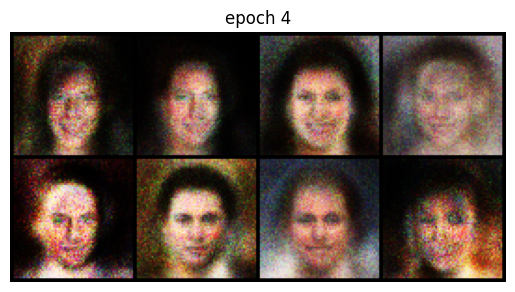

for each: 5/5... batch: 1... G-loss:1.737779140472412... D-loss:0.5026127099990845
for each: 5/5... batch: 51... G-loss:1.7504234313964844... D-loss:0.48556095361709595
for each: 5/5... batch: 101... G-loss:1.7499775886535645... D-loss:0.444575697183609
for each: 5/5... batch: 151... G-loss:1.9026845693588257... D-loss:0.4582323431968689
for each: 5/5... batch: 201... G-loss:1.4833060503005981... D-loss:0.5736842155456543
for each: 5/5... batch: 251... G-loss:1.4883594512939453... D-loss:0.48149892687797546
for each: 5/5... batch: 301... G-loss:1.4817204475402832... D-loss:0.5275849103927612
for each: 5/5... batch: 351... G-loss:1.478001356124878... D-loss:0.4854770004749298
for each: 5/5... batch: 401... G-loss:1.8095409870147705... D-loss:0.4107092022895813
for each: 5/5... batch: 451... G-loss:1.758548378944397... D-loss:0.46344172954559326
for each: 5/5... batch: 501... G-loss:1.5880486965179443... D-loss:0.470816433429718
for each: 5/5... batch: 551... G-loss:1.6487020254135132...

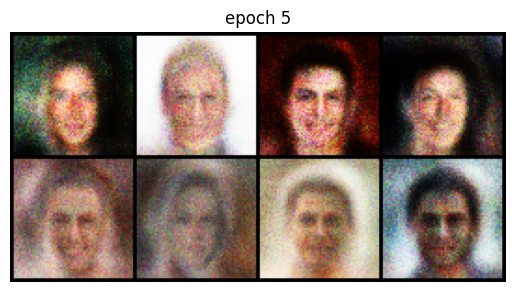

In [48]:
Train(generator, discriminator, dataloader, epochs=5)

## Last Training Conslucsion: -

The GAN was trained for **5 epochs** on the CelebA dataset.

During training:

- **Generator loss decreased overall** from high unstable values (~5.40) to lower (~1.5-2.0)

- **Discriminator loss increased gradually** from ~0.15 to ~0.53

- This indicates the Generator improved and started prodcuing more realistic fake images.

- Discriminator became less confident because fake images were harder to detect.